<a href="https://colab.research.google.com/github/R12-l/2023-Java-creando-tu-primera-aplicacion/blob/aula-1/covid_muertes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📅 Fecha del pico más alto de muertes diarias: 2021-01-24
💀 Número de muertes ese día: 9877
🧮 Total de muertes acumuladas al final del periodo: 334551


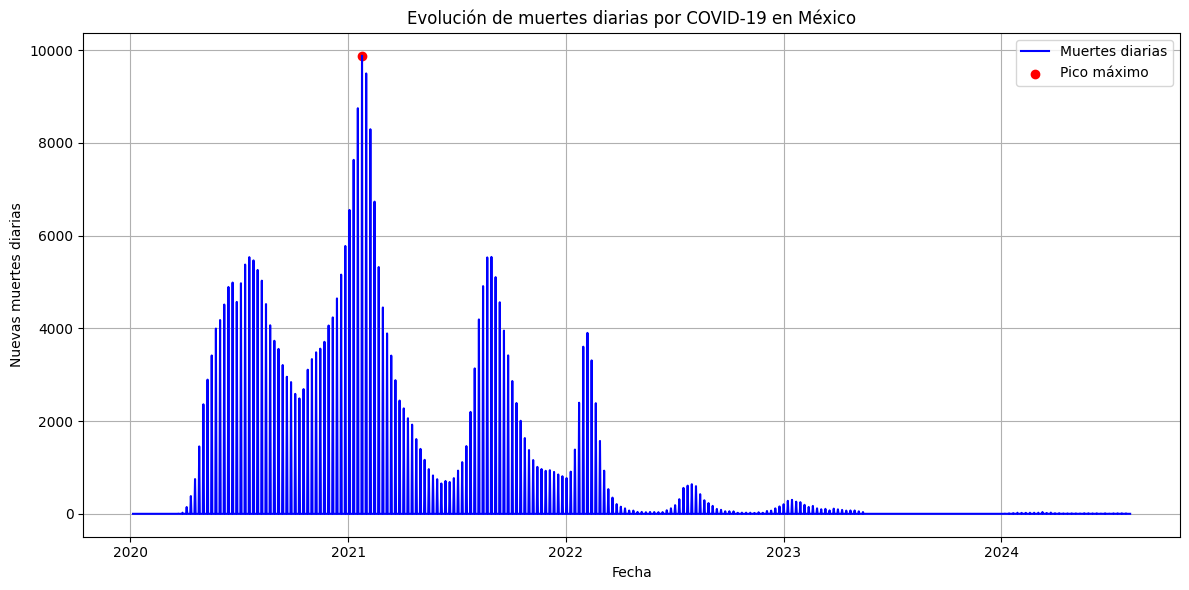

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Paso 1: Cargar datos desde la URL
url = "https://covid.ourworldindata.org/data/owid-covid-data.csv"
df = pd.read_csv(url)

# Paso 2: Filtrar solo los datos de México
df_mexico = df[df['location'] == 'Mexico'].copy()

# Asegurarse de que la columna 'date' es tipo fecha
df_mexico['date'] = pd.to_datetime(df_mexico['date'])

# Paso 3: Calcular nuevas muertes diarias
df_mexico['nuevas_Muertes_Diarias'] = df_mexico['total_deaths'].diff()

# Paso 4: Encontrar pico más alto de nuevas muertes
pico = df_mexico.loc[df_mexico['nuevas_Muertes_Diarias'].idxmax()]
fecha_pico = pico['date']
valor_pico = pico['nuevas_Muertes_Diarias']

# Paso 5: Obtener total acumulado de muertes al final del periodo
total_muertes = df_mexico['total_deaths'].iloc[-1]

# Mostrar resultados por pantalla
print(f"📅 Fecha del pico más alto de muertes diarias: {fecha_pico.date()}")
print(f"💀 Número de muertes ese día: {int(valor_pico)}")
print(f"🧮 Total de muertes acumuladas al final del periodo: {int(total_muertes)}")

# Paso 6: Graficar evolución de muertes diarias
plt.figure(figsize=(12, 6))
plt.plot(df_mexico['date'], df_mexico['nuevas_Muertes_Diarias'], label='Muertes diarias', color='blue')
plt.scatter(fecha_pico, valor_pico, color='red', label='Pico máximo')
plt.title('Evolución de muertes diarias por COVID-19 en México')
plt.xlabel('Fecha')
plt.ylabel('Nuevas muertes diarias')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [2]:
print(df_mexico[['date', 'total_deaths', 'nuevas_Muertes_Diarias']].head(10))
suma_muertes_diarias = df_mexico['nuevas_Muertes_Diarias'].sum()
negativas = df_mexico[df_mexico['nuevas_Muertes_Diarias'] < 0]

             date  total_deaths  nuevas_Muertes_Diarias
243694 2020-01-01           NaN                     NaN
243695 2020-01-02           NaN                     NaN
243696 2020-01-03           NaN                     NaN
243697 2020-01-04           NaN                     NaN
243698 2020-01-05           0.0                     NaN
243699 2020-01-06           0.0                     0.0
243700 2020-01-07           0.0                     0.0
243701 2020-01-08           0.0                     0.0
243702 2020-01-09           0.0                     0.0
243703 2020-01-10           0.0                     0.0


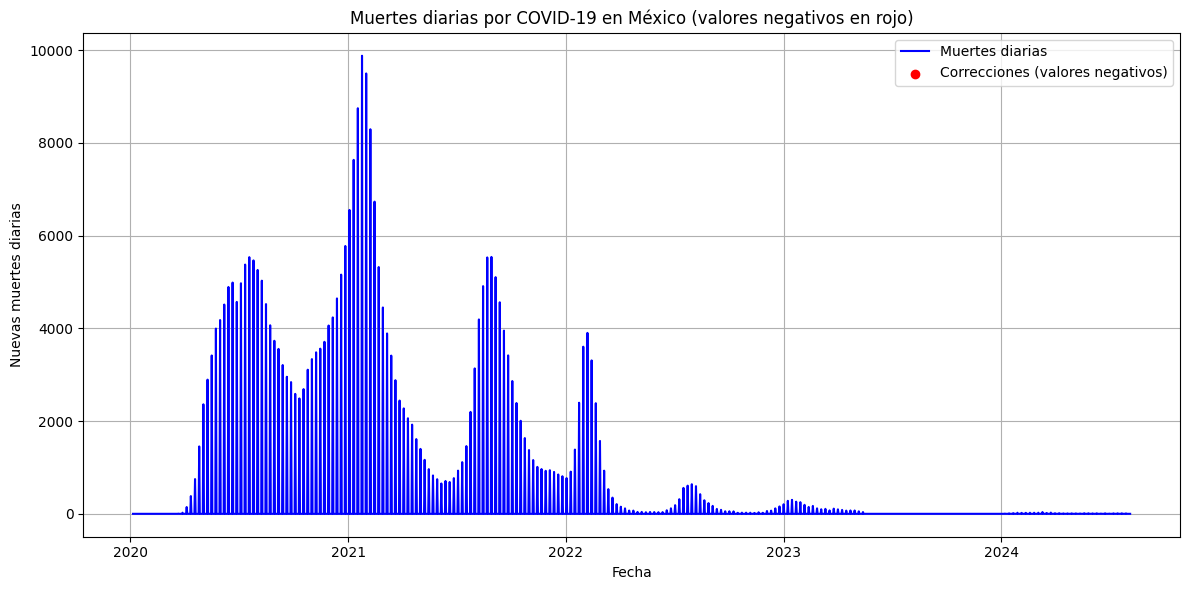

In [3]:
# Graficar todas las muertes diarias en azul
plt.figure(figsize=(12, 6))
plt.plot(df_mexico['date'], df_mexico['nuevas_Muertes_Diarias'], label='Muertes diarias', color='blue')

# Filtrar días con muertes negativas y graficarlos como puntos rojos
negativas = df_mexico[df_mexico['nuevas_Muertes_Diarias'] < 0]
plt.scatter(negativas['date'], negativas['nuevas_Muertes_Diarias'], color='red', label='Correcciones (valores negativos)', zorder=5)

# Títulos y etiquetas
plt.title('Muertes diarias por COVID-19 en México (valores negativos en rojo)')
plt.xlabel('Fecha')
plt.ylabel('Nuevas muertes diarias')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()